In [1]:
import numpy as np
from utils import *
from StateEstimatorVINS import StateEstimatorMPF
from UAVCamera import UAVCamera
from AerialImageModel import AerialImageModel
from DataBaseScanner import DatabaseScanner
from FeatureDetectorMatcher import FeatureDetectorMatcher
from Timer import Timer
import pymap3d as pm
import matplotlib.pyplot as plt


Using device: cuda
Using device: cuda
Using device: cuda


In [ ]:
#### Flight parameters
ReferenceFrame = 'NED'  #Reference frame for the drone's local coordinate system
MAP            = 'bacikoy'  #Satallite map name
detector       = 'XFEAT'   #Feature detector type (SP: SuperPoint, ORB: Oriented FAST and Rotated Brief)
snapFrame      = True
IMUtype        = 2  #deal later
LLA_leftupper  = [39.780238,  32.314440, 0]  # LLA reference point (latitude, longitude) left upper corner of the map
LLA_home       = [39.7785834, 32.3158889,0] # Initial position of the drone in LLA (latitude, longitude, altitude)
leftupperNED   = np.array(pm.geodetic2ned(LLA_leftupper[0], LLA_leftupper[1], LLA_leftupper[2], LLA_home[0], LLA_home[1], LLA_home[2]), dtype=float) + np.array([5,-8,0])


detector_opt = {'type' : 'XFEAT'}
hFeatureDM = FeatureDetectorMatcher(detector_opt)

preFeatureFlag = True
hAIM = AerialImageModel(MAP, FeatureDM = hFeatureDM, preFeatureFlag= preFeatureFlag)
hAIM.leftupperNED = leftupperNED


snapDim = (280,280) #deal later
gimballedCamera       = True
useGAN                = False
showFeatures          = False
showFrame             = True
liveFlag              = True  # live video flag, if true, use the live image from the UAV camera, if false, use the recorded video

batch_mode = False
hDB = DatabaseScanner(FeatureDM = hFeatureDM, AIM=hAIM, snapDim=snapDim, 
                      showFeatures= showFeatures, showFrame= showFrame,
                      batch_mode = batch_mode)

Using device: cuda
Satellite Image Map Loaded with 17224 features


Using cache found in /home/ituarc/.cache/torch/hub/verlab_accelerated_features_main
/home/ituarc/.local/lib/python3.10/site-packages/torch/storage.py:505: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to t

In [3]:
part1pose = np.array([-0.17830983865465977 - 3, 3.9015089966618093 + 10, 0.0])
yaw1 = 0
ParticlesKp,ParticlesDesc = hDB.findParticlesKeypointDescriptors(np.array([part1pose,[50,0,0]]),np.array(np.deg2rad([yaw1,0])))

yaw particle: [0. 0.]


Width: 280, Height: 280


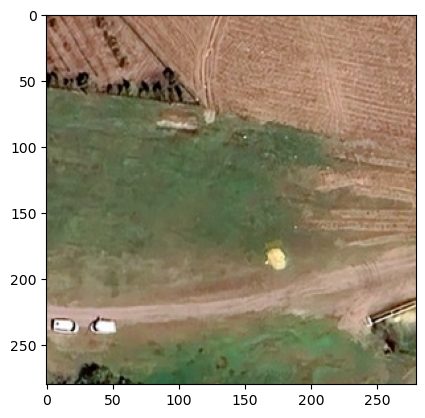

In [4]:
FramemostLikelihoodPart   = hDB.snapPartImage(part1pose,np.deg2rad(yaw1),ParticlesKp[0])
plt.imshow(FramemostLikelihoodPart)

In [5]:
ParticlesDesc[0]['keypoints'].shape

torch.Size([1596, 2])

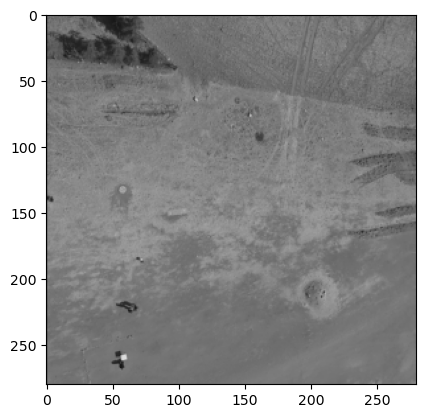

In [13]:
# frame = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0054_20251018_211221.jpg"
# frame = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0020_20251018_211147.jpg"
frame = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/540/frame_0019_20251018_211146.jpg"


# frame = "/home/ituarc/Documents/Github/FeatureMatching-PythonCODE/captured_frames_bacikoy/satellite/1400/bacikoy_sat (1).jpg"



frame = cv2.imread(frame)
d = 280
frame = resize_image(frame, (d,d))

keypoints, keypoints_np, descriptors = hFeatureDM.detectFeatures(frame)
plt.imshow(frame)

In [14]:
descriptors['keypoints'].shape

torch.Size([1605, 2])

In [21]:
matches = hFeatureDM.matchFeatures(keypoints_np, descriptors, ParticlesKp, ParticlesDesc)

np.sum(matches[0])

number of kps UAV and Part: 1605, 1596
[XFEAT LightGlue Matching]
Elapsed: 0.11597514152526855
number of kps UAV and Part: 1605, 1784
[XFEAT LightGlue Matching]
Elapsed: 0.15719223022460938


4

In [18]:
keypoints_np.shape

(1605, 2)

In [63]:
# matches = xfeat.match_lighterglue(descriptors, ParticlesDesc[0])

matches = hFeatureDM.matchFeatures(keypoints_np,descriptors, ParticlesKp,ParticlesDesc)
mkpts_0 = matches[0]
mkpts_1 = matches[1]


canvas = warp_corners_and_draw_matches(mkpts_0, mkpts_1, frame, FramemostLikelihoodPart)
plt.figure(figsize=(12,12))
plt.imshow(canvas[..., ::-1]), plt.show()

number of kps UAV and Part: 1251, 789
[XFEAT LightGlue Matching]
Elapsed: 0.04398083686828613
number of kps UAV and Part: 1251, 786
[XFEAT LightGlue Matching]
Elapsed: 0.041962623596191406


ValueError: cannot reshape array of size 57 into shape (1,2)

In [32]:
matches

[array([False,  True, False,  True,  True,  True,  True, False, False,
         True,  True,  True,  True, False,  True,  True,  True,  True,
        False, False,  True, False,  True,  True,  True,  True, False,
        False,  True, False, False, False,  True, False, False,  True,
        False,  True,  True, False, False, False, False,  True, False,
        False, False]),
 array([ True, False, False,  True,  True,  True, False, False, False,
        False,  True, False,  True, False,  True,  True,  True,  True,
         True,  True,  True, False, False, False,  True, False, False,
        False,  True, False, False,  True,  True, False, False,  True,
        False, False,  True, False,  True,  True, False, False, False,
        False, False,  True, False,  True, False,  True, False, False,
         True, False])]

In [11]:
def warp_corners_and_draw_matches(ref_points, dst_points, img1, img2):
    # Calculate the Homography matrix
    # H, mask = cv2.findHomography(ref_points, dst_points, cv2.USAC_MAGSAC, 3.5, maxIters=1_000, confidence=0.999)
    # mask = mask.flatten()



    # OpenCV expects points as (x, y) float32
    src_pts = np.array(ref_points, dtype=np.float32).reshape(-1, 1, 2)
    dst_pts = np.array(dst_points, dtype=np.float32).reshape(-1, 1, 2)

    # For 'similarity', we can use estimateAffinePartial2D
    _, mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC,
                                                 ransacReprojThreshold=5)   # NOTE: CHECK SPEED OF RANSAC
    
    mask = mask.flatten().astype(bool)

    print('inlier ratio: ', np.sum(mask)/len(mask))
    print('num inliers: ', np.sum(mask))
    
    

    # # Get corners of the first image (image1)
    # h, w = img1.shape[:2]
    # corners_img1 = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32).reshape(-1, 1, 2)

    # # Warp corners to the second image (image2) space
    # warped_corners = cv2.perspectiveTransform(corners_img1, H)

    # # Draw the warped corners in image2
    # img2_with_corners = img2.copy()
    # for i in range(len(warped_corners)):
    #     start_point = tuple(warped_corners[i-1][0].astype(int))
    #     end_point = tuple(warped_corners[i][0].astype(int))
    #     cv2.line(img2_with_corners, start_point, end_point, (0, 255, 0), 4)  # Using solid green for corners

    # Prepare keypoints and matches for drawMatches function
    keypoints1 = [cv2.KeyPoint(p[0], p[1], 5) for p in ref_points]
    keypoints2 = [cv2.KeyPoint(p[0], p[1], 5) for p in dst_points]
    matches = [cv2.DMatch(i,i,0) for i in range(len(mask)) if mask[i]]

    # Draw inlier matches
    img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches, None,
                                  matchColor=(0, 255, 0), flags=2)

    return img_matches

In [12]:
import torch
xfeat = torch.hub.load('verlab/accelerated_features', 'XFeat', pretrained = True, top_k = 1300)

Using cache found in /home/ituarc/.cache/torch/hub/verlab_accelerated_features_main


In [10]:

matches

(array([[ 838.3721  , 1226.0175  ],
        [ 851.5988  , 1197.529   ],
        [ 843.4593  , 1241.279   ],
        [ 883.1395  ,  826.1628  ],
        [ 698.98254 , 1238.2268  ],
        [ 765.1163  , 1223.9825  ],
        [ 846.51166 , 1245.3489  ],
        [ 671.51166 , 1200.5814  ],
        [ 686.77325 , 1205.6686  ],
        [1301.3081  , 1343.0233  ],
        [ 708.1395  , 1239.2441  ],
        [1074.4186  ,  344.91278 ],
        [ 783.43024 , 1237.2094  ],
        [1048.9825  ,  366.27908 ],
        [ 837.3547  , 1233.1395  ],
        [1240.2616  ,  459.88373 ],
        [ 755.9593  , 1234.157   ],
        [1225.      , 1318.6046  ],
        [ 854.6512  , 1242.2965  ],
        [ 622.67444 ,  840.407   ],
        [ 847.52905 ,  651.1628  ],
        [1282.9941  ,  452.76163 ],
        [1206.686   ,  841.42444 ],
        [ 936.0465  ,  356.10464 ],
        [ 846.51166 , 1236.1919  ],
        [ 903.4884  ,  361.19186 ],
        [ 541.27905 ,  341.86047 ],
        [ 850.5814  , 1044.9

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rclpy
from rclpy.executors import MultiThreadedExecutor
import time
import pymap3d as pm
import csv
import sys
import os
import yaml
import logging
import threading
import signal
from pathlib import Path
from datetime import datetime

In [2]:
from OV.PixhawkCommander import PixhawkCommander

rclpy.init()
node_PixhawkCMD  = PixhawkCommander()
# Create a multithreaded executor and add both nodes
executor = MultiThreadedExecutor()
executor.add_node(node_PixhawkCMD)
spin_thread = threading.Thread(target=executor.spin, daemon=True)
spin_thread.start()


In [3]:
while True:
    
    node_PixhawkCMD.set_attitude(np.deg2rad([0, 45, 30]), thrust=1)
    
    time.sleep(0.01)


[INFO] [1761087458.181323402] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.194248902] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.206545796] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.218550709] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.231830433] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.243750062] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.256877971] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.268815201] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.285830364] [pixhawk_commander]: Published attitude setpoint: q=[ 90. -45.  30.], thrust=1
[INFO] [1761087458.

KeyboardInterrupt: 

tensor([[ 838.3721, 1226.0175],
        [ 350.0000, 1280.9594],
        [ 837.3547, 1237.2094],
        ...,
        [ 450.7267,  321.5116],
        [ 791.5698,  502.6163],
        [ 984.8837,  826.1628]], device='cuda:0')

In [23]:
from time import time

for i in range(5):
    start_time = time()
    for i in range(1):
        rotated_patch = extract_rotated_patch_optimized(
            satellite_image,
            center_point,
            patch_size,
            yaw
        )
    end_time = time()
    print(f"Time taken to extract rotated patch: {end_time - start_time:.4f} seconds")

Time taken to extract rotated patch: 0.0023 seconds
Time taken to extract rotated patch: 0.0012 seconds
Time taken to extract rotated patch: 0.0011 seconds
Time taken to extract rotated patch: 0.0018 seconds
Time taken to extract rotated patch: 0.0082 seconds


In [ ]:

R = quat2rotm(eul2quat(np.deg2rad([45, 0, 0])))  


In [11]:
R  @ np.array([[1, 0, 0]]).T  # Rotate the vector [1, 0, 0] by the rotation matrix R

array([[0.70710678],
       [0.70710678],
       [0.        ]])

In [ ]:
np.array([1, 0, 0]).T.

(3,)

In [44]:

mag = np.array([100, 56, 0])  # Example magnetometer reading
quat = eul2quat(np.deg2rad([0, -30, 0]))  # Example quaternion from MAVROS
quat_mavros = quat[1], quat[2], quat[3], quat[0]  # Reorder to [w, x, y, z]
heading = calculate_heading(mag, quat_mavros, 0)
print(f"Heading: {np.rad2deg(heading)} degrees")


Heading: 32.888013823689334 degrees


In [3]:
quat_mavros

(0.0, 0.0, 0.0, 1.0)

In [15]:
heading

0.8068730671576461

In [59]:
np.random.seed(0)
R = np.random.rand(3, 3)
R_tile = np.tile(R, (4, 1, 1))

print(R)


print(R_tile.shape)

v = np.random.rand(3)
print(v)
print(v.shape)

print((R_tile.dot(v)))

print((5*(R_tile @ v)))



[[0.5488135  0.71518937 0.60276338]
 [0.54488318 0.4236548  0.64589411]
 [0.43758721 0.891773   0.96366276]]
(4, 3, 3)
[0.38344152 0.79172504 0.52889492]
(3,)
[[1.0954697  0.88595906 1.38350446]
 [1.0954697  0.88595906 1.38350446]
 [1.0954697  0.88595906 1.38350446]
 [1.0954697  0.88595906 1.38350446]]
[[5.4773485  4.42979531 6.91752228]
 [5.4773485  4.42979531 6.91752228]
 [5.4773485  4.42979531 6.91752228]
 [5.4773485  4.42979531 6.91752228]]


In [ ]:
from scipy.stats import norm

norm.ppf(0.6)

np.float64(0.2533471031357997)

In [259]:
1746433619173440000 + (0.1)*1e9

1.74643361927344e+18

In [87]:
arr = np.arange(10)


# arr = np.random.shuffle(arr)
# print(arr)

a = np.random.shuffle(arr)
print(a)


None


In [9]:
from utils import *

wrap2_pi(np.random.rand(1,10))

array([[ 0.69355581,  2.5811645 ,  2.34115902,  0.61717768,  3.08772877,
         1.37051904,  1.70509866,  2.21379594, -2.77592676,  0.99302111]])

In [257]:
1 / (1403636579813550000 - 1403636579863550000) * 1e9

-20.0

In [245]:
fold = 'data/videos/itu_video_05052025.npy'
dt = np.load(fold)
import cv2

In [250]:
dt[1200].shape

(256, 256, 3)

In [255]:
cv2.imshow('a',cv2.resize(dt[1200], (600,600)))
cv2.waitKey(0)
cv2.destroyAllWindows()


In [69]:
alt                     = 100
rotM_hypo               = quat2rotm(eul2quat(np.deg2rad([0,45,-30])))                           # shape (N, 3, 3)
range_fimder_body       = np.array([0, 0, 1])                       # Assuming the range is in the Z direction
range_finder_world      = rotM_hypo @ range_fimder_body             # shape (N, 3)
scale                   = abs(alt) / range_finder_world[2]  # shape (N,)
delta_pos               = range_finder_world * scale.reshape(-1,1)  # shape (N, 3)
print(delta_pos)

[[100.          81.64965809 100.        ]]


In [54]:
m = arr.shape[0]

with Timer('a'):
    
    for i in range(50000):

        drop_idx = np.random.choice(m, size=n, replace=False)  # O(n)
        new_arr  = np.delete(arr, drop_idx, axis=0)            # O((m-n)*k)

[a]
Elapsed: 0.48070287704467773


In [14]:
new_arr

array([ 1,  6,  8, 10, 13, 15, 17, 18, 19, 20, 22, 24, 26, 27, 30, 31, 32,
       34, 36, 38, 44, 49, 50, 51, 52, 53, 55, 57, 59, 60, 62, 63, 65, 66,
       67, 70, 72, 80, 81, 82, 83, 84, 86, 87, 88, 90, 92, 93, 96, 98])

In [1]:
import numpy as np

def resample_equal_spacing(waypoints):
    """
    Take a list of NED waypoints and resample so that every segment is split
    into equal lengths, where the step size is the smallest original segment length.
    """
    wps = np.array(waypoints, dtype=float)

    # Step 1: compute distances between each waypoint pair
    distances = np.linalg.norm(np.diff(wps, axis=0), axis=1)

    # Step 2: find the minimum segment length
    d_min = np.min(distances) / 2
    print(f"Minimum segment length: {d_min}")

    new_wps = [wps[0]]  # always keep first waypoint

    # Step 3: iterate through segments and interpolate
    for i in range(len(wps) - 1):
        p1 = wps[i]
        p2 = wps[i + 1]

        segment_vec = p2 - p1
        segment_len = np.linalg.norm(segment_vec)

        # number of uniform steps needed
        steps = int(np.round(segment_len / d_min))

        # unit direction vector
        direction = segment_vec / segment_len

        # insert extra points
        for k in range(1, steps + 1):
            new_point = p1 + k * d_min * direction
            new_wps.append(new_point)

    return np.array(new_wps)


In [2]:
# wp_list = [[0, 0, 0],
#            [0, -200, 0],
#            [200, -200, 0],
# [200, 0, 0],

#            [0, 0, 0]]


# wp_list = [[0, 0, 0],
#            [0, -100, 0],
#            [100, -100, 0],
#            [100, 0, 0],
#            [0, 0, 0],
#            [0, -100, 0],
#            [100, -100, 0],
#            [100, 0, 0],
#            [0, 0, 0],
#            [0, -100, 0],
#            [100, -100, 0],
#            [100, 0, 0],
#            [0, 0, 0]]
# wp_list = [[0, 0, 0],
#            [200, 0, 0],
#            [200, -200, 0],
#            [100, -200, 0],
#            [100, -100, 0],
#            [50,  -100, 0],
#            [50, -200, 0],
#            [0, -200, 0],
#            [0,  0, 0],
#            [200, 0, 0],
#            [200, -200, 0],
#            [100, -200, 0],
#            [100, -100, 0],
#            [50,  -100, 0],
#            [50, -200, 0],
#            [0, -200, 0],
#            [0,  0, 0]]

# wp_list = [[0, 0, 0],
#            [100, 0, 0],
#            [100, 500, 0],
#            [500, 500, 0],
#            [500, 200, 0],
#            [200, 200, 0],
#            [200, 0, 0],
#            [0, 0, 0]]

wp_list = [[0, 0, 0],
            [50, 0, 0],
            [50, -250, 0],
            [250, -250, 0],
            [250, -100, 0],
            [100, -100, 0],
            [100, 0, 0],
            [0, 0, 0]]


In [3]:
new_wps = resample_equal_spacing(wp_list)


Minimum segment length: 25.0


In [4]:

from OV.utils_OV.guidance_utils import TrajectoryGeneratorV2 
from OV.utils_OV.common_utils import  visualize2DgenTraj

traj = TrajectoryGeneratorV2(sampling_freq=20, max_vel=[8.0, 8.0, 8.0], max_acc=[8.0, 8.0, 8.0])

# traj.generate_traj_from_wplist_interp(new_wps, coordinate_type="ned")
# generated_traj = traj.get_pos_vel_acc_in_ned()
wp_list = traj.resample_equal_spacing(wp_list)
traj.generate_traj_from_wplist_interp(wp_list, coordinate_type="ned")
generated_traj = traj.get_pos_vel_acc_in_ned()

# wp_list = traj.generate_wp_list_for_square_trajectory(200, 0, edge_inter_cp = 2, order = 'WN') # order = 'NW' or 'WN'
# traj.generate_traj_from_wplist_interp(np.array(wp_list), coordinate_type="ned")
# generated_traj = traj.get_pos_vel_acc_in_ned()


Resampling waypoints with step size of:  50
u: 0.0
pos [0. 0. 0.]
u: 0.0
pos [0. 0. 0.]
u: 0.0500057592462074
pos [1.69457204e-03 7.86984983e-07 0.00000000e+00]
u: 0.1000115184924148
pos [6.76286980e-03 6.29587986e-06 0.00000000e+00]
u: 163.36881545735957
pos [ 6.75501261e-03 -1.56131352e-06  0.00000000e+00]
u: 163.41882121660578
pos [ 1.69358989e-03 -1.95164189e-07  0.00000000e+00]


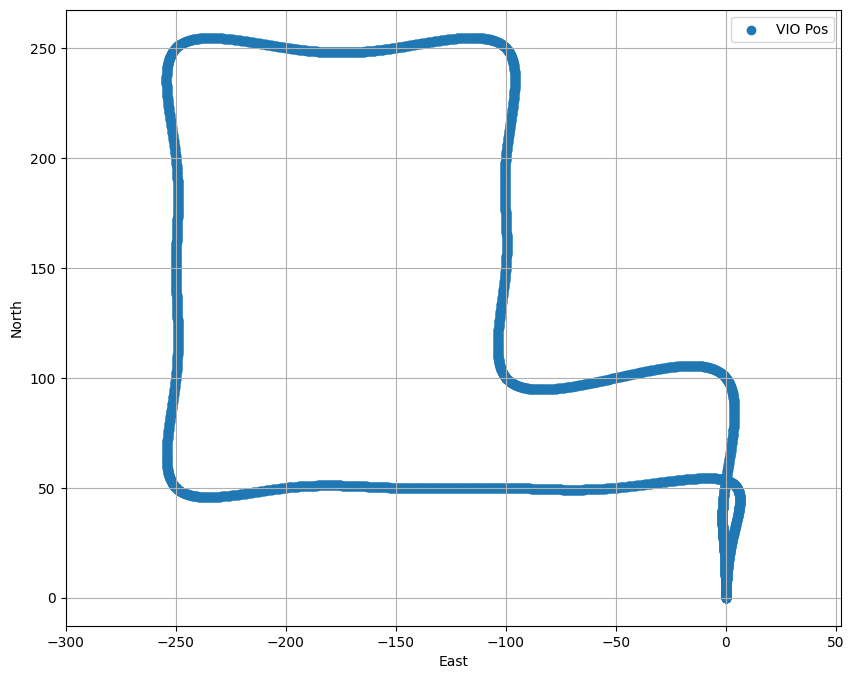

In [5]:
visualize2DgenTraj(generated_traj['pos'][:,0:2])


In [6]:
wp_list = traj.generate_wp_list_for_square_trajectory(50, 0, edge_inter_cp = 1, order = 'WN') # order = 'NW' or 'WN'
wp_list = np.array(wp_list)
shaped_wp_list = wp_list
traj.generate_traj_from_wplist_interp(shaped_wp_list, coordinate_type="ned")

2
u: 0.0
pos [0. 0. 0.]


In [7]:
wp_list

array([[  0.,   0.,   0.],
       [  0., -25.,   0.],
       [  0., -50.,   0.],
       [ 25., -50.,   0.],
       [ 50., -50.,   0.],
       [ 50., -25.,   0.],
       [ 50.,   0.,   0.],
       [ 25.,   0.,   0.],
       [  0.,   0.,   0.]])

In [ ]:
def climb(node_OdomVIO, VIO_pos_first, Vel_zero,pos_controller_x,pos_controller_y,alt_target_climb,alt_thresh_climb_low,DEFAULT_TAKEOFF_THRUST):
    if CLIMB:
        # Get odometry data from VIO
        VIO_dict = node_OdomVIO.VIOned.dict.copy()
        VIO_pos = np.array(VIO_dict['position'])
    VIO_vel = np.array(VIO_dict['velocity'])

    # Lateral position control
    ref_pos, ref_vel = VIO_pos_first, Vel_zero

    # Get reference position and velocity from trajectory generation
    #traj_id_climb +=1
    #if traj_id_climb >= len(generated_traj_climb["pos"])-1:
    #    traj_id_climb = len(generated_traj_climb["pos"])-1
    #ref_pos = generated_traj_climb["pos"][traj_id_climb,:].copy()
    #ref_vel = generated_traj_climb["vel"][traj_id_climb,:].copy()
    #ref_acc = generated_traj_climb["acc"][traj_id_climb,:].copy()

    acc_cmd_x = pos_controller_x.update(ref_pos[0], ref_vel[0], VIO_pos[0], VIO_vel[0])
    acc_cmd_y = pos_controller_y.update(ref_pos[1], ref_vel[1], VIO_pos[1], VIO_vel[1])
    acc_cmd_xy = np.array([acc_cmd_x, acc_cmd_y, 0]) 

    a_n = acc_cmd_xy[0]
    a_e = acc_cmd_xy[1]

    yaw_target = 0.0
    pitch_target, roll_target = from_pos_vel_to_angle_ref(a_n, a_e, 0, yaw_target, yaw_in_degrees=True, max_accel=max_acc)

    # Vertical position control
    alt_diff = alt_target_climb - (-VIO_pos[2])

    if alt_diff > 5:

        print("Climbing to target altitude: ", alt_target_climb, "Current altitude: ", -VIO_pos[2], "diff: ", alt_diff)
        if alt_diff > alt_thresh_climb_low:
            thrust_target = DEFAULT_TAKEOFF_THRUST

        else:
            thrust_target = max(min(0.5 + (0.2/alt_thresh_climb_low) * alt_diff, DEFAULT_TAKEOFF_THRUST), 0.5)
    else:
        thrust_target = 0.5
        CLIMB = False
        print('Climb altitude reached...')


        # Generating trajectory from waypoints
        wp_list = np.array(wp_list)
        shaped_wp_list = wp_list + VIO_pos
        traj.generate_traj_from_wplist_interp(shaped_wp_list, coordinate_type="ned")
        generated_traj = traj.get_pos_vel_acc_in_ned()
        

    node_PixhawkCMD.set_attitude(np.deg2rad([yaw_target, pitch_target, roll_target]), thrust=thrust_target)
    

    if last_print_time + 1 < time.time():
    print("diff_pos: " , ref_pos - VIO_pos)
    print('diff_vel: ' , ref_vel - VIO_vel)
    print("VIO pos:", VIO_pos)
    print("VIO vel:", VIO_vel)
    print("ref_pos:", ref_pos)
    print("ref_vel:", ref_vel)
    print("acc:", a_n, a_e)
    print("RPY:",yaw_target, pitch_target, roll_target)
    last_print_time = time.time()
    
    return CLIMB




In [1]:
if 3 > 2:
    print('yes')

elif 3 < 2:

    print('no')
    


yes
